# Inspect nightly Black Marble A2 over Dyer County

This notebook reads the completed **VNP46A2 Collection 002** cache: February 5–April 17, 2025. It makes no network requests and uses no TING data.

We inspect observation availability, build a descriptive pre-event radiance reference, and compare individual nights and cells. **These are exploratory radiance differences, not outage estimates or causal results.** Product dates are not exact local observation times.

Use this repository's `.venv` kernel and **Run All**. The final cells write QGIS-ready layers into the mounted `data/published/viirs_dyer/` directory. Changing the settings and rerunning replaces those derived inspection layers; source files remain in the ingestion cache.

In [1]:
import os
import tempfile
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ntl-matplotlib"))
import json
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display
import rasterio
from rasterio.transform import rowcol, xy

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts/ingest_viirs.py").exists())
sys.path.insert(0, str(ROOT))
from scripts.ingest_viirs import cog, digest, save_json
DATA = ROOT / "data/viirs/VNP46A2.002"
PUBLISH = ROOT / "data/published/viirs_dyer"
BASELINE_END = "2025-04-01"
INSPECT_DATE = "2025-04-03"
MAP_DATES = ["2025-04-03", "2025-04-07", "2025-04-08"]
MIN_BASELINE_NIGHTS = 10  # Exploratory support rule, not an outage threshold; vary to inspect sensitivity.
WRITE_QGIS_EXPORTS = True

manifest = json.loads((DATA / "manifest.json").read_text())
assert manifest["status"] in ("complete", "complete_with_missing_dates"), manifest["status"]
coverage = pd.read_csv(DATA / "coverage.csv")
dates = pd.DatetimeIndex(coverage["date"])
labels = dates.strftime("%Y-%m-%d").tolist()
print("Kernel:", sys.executable)
print("Dataset:", manifest["product"], manifest["collection"], manifest["start"], "to", manifest["end"])
display(coverage.head())

Kernel: /home/daynan/research/ntl-outage-detection/.venv/bin/python
Dataset: VNP46A2 002 2025-02-05 to 2025-04-17


,date,status,county_cells,radiance_present_cells,confident_clear_cells,strict_usable_cells,strict_usable_percent,source_filename
0,2025-02-05,complete,7868,1190,1190,93,1.182003,VNP46A2.A2025036.h09v05.002.2025048000426.h5
1,2025-02-06,complete,7868,285,285,208,2.643620,VNP46A2.A2025037.h09v05.002.2025048001408.h5
2,2025-02-07,complete,7868,1402,1445,718,9.125572,VNP46A2.A2025038.h09v05.002.2025049174121.h5
3,2025-02-08,complete,7868,1051,1119,476,6.049822,VNP46A2.A2025039.h09v05.002.2025049194936.h5
4,2025-02-09,complete,7868,863,890,569,7.231825,VNP46A2.A2025040.h09v05.002.2025049213530.h5


## Load the small native-grid stack

The arrays have dimensions **date × row × column**. Every file uses the same 15 arc-second grid. The county mask uses cell centers; neighboring cells in the rectangular crop are retained but excluded from summaries. Radiance is in nW·cm⁻²·sr⁻¹; this Collection 2 layer has scale 1.

Missing radiance becomes `NaN`. Raw cloud/quality flags remain integers. The `strict_usable` mask was created during ingestion: valid corrected radiance, mandatory QA=0, high-quality confidently clear nighttime mask, no IR cirrus, and snow flag=0. Gap-filled radiance is retained **only for diagnostic display**.

In [10]:
first = DATA / "dyer" / labels[0]
with rasterio.open(first / "county_mask.tif") as src:
    county = src.read(1).astype(bool)
    affine, crs = src.transform, src.crs
    bounds = src.bounds
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
shape = county.shape

def read_stack(name, floating=False):
    result = []
    for day, status in zip(labels, coverage["status"]):
        if status != "complete":
            result.append(np.full(shape, np.nan if floating else (0 if name == "strict_usable" else 65535)))
            continue
        with rasterio.open(DATA / "dyer" / day / f"{name}.tif") as src:
            assert src.transform == affine and src.crs == crs and src.shape == shape
            if floating:
                values = src.read(1, masked=True).astype("float32").filled(np.nan)
                values = values * src.scales[0] + src.offsets[0]
            else:
                values = src.read(1)
            result.append(values)
    return np.stack(result)

raw = read_stack("radiance", floating=True)
gap_filled = read_stack("gap_filled_radiance", floating=True)
cloud = read_stack("cloud_mask").astype("uint16")
mandatory = read_stack("mandatory_quality").astype("uint16")
snow = read_stack("snow_flag").astype("uint16")
strict = read_stack("strict_usable").astype(bool)
observed = np.where(strict & county[None, :, :], raw, np.nan)
baseline_idx = dates <= pd.Timestamp(BASELINE_END)
event_idx = ~baseline_idx
assert baseline_idx.any() and event_idx.any()
print(f"Stack: {raw.shape}; county cell centers: {county.sum():,}")
print("Baseline dates:", baseline_idx.sum(), "Event dates:", event_idx.sum())

Stack: (72, 81, 139); county cell centers: 7,868
Baseline dates: 56 Event dates: 16


## How much of each night is observable?

The shaded interval marks the April 2–8 event sequence using calendar labels; it is not a precise overpass alignment. A value of zero means no cells pass screening, **not zero light or zero outages**.

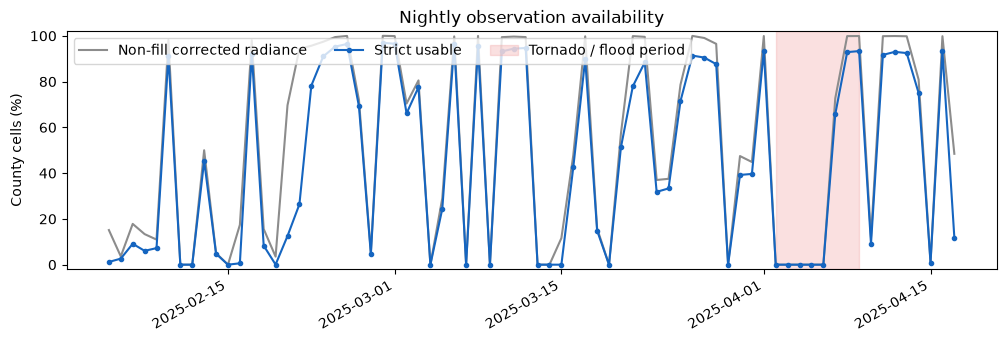

,date,radiance_present_cells,strict_usable_cells,strict_usable_percent
56,2025-04-02,0,0,0.000000
57,2025-04-03,0,0,0.000000
58,2025-04-04,0,0,0.000000
59,2025-04-05,0,0,0.000000
60,2025-04-06,0,0,0.000000
61,2025-04-07,5719,5174,65.760041
62,2025-04-08,7858,7307,92.869853
63,2025-04-09,7861,7344,93.340112
64,2025-04-10,931,713,9.062023
65,2025-04-11,7856,7212,91.662430


In [11]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(dates, coverage["radiance_present_cells"] / county.sum() * 100, label="Non-fill corrected radiance", color="0.55")
ax.plot(dates, coverage["strict_usable_percent"], label="Strict usable", color="#1565c0", marker=".")
ax.axvspan(pd.Timestamp("2025-04-02"), pd.Timestamp("2025-04-09"), color="#ef9a9a", alpha=.3, label="Tornado / flood period")
ax.set(ylabel="County cells (%)", ylim=(-2, 102), title="Nightly observation availability")
ax.legend(loc="upper left", ncol=3)
fig.autofmt_xdate()
plt.show()
display(coverage.loc[event_idx, ["date", "radiance_present_cells", "strict_usable_cells", "strict_usable_percent"]])

## Why are early-event observations rejected?

These reasons overlap: one cell can be cloudy, have poor mandatory QA, and lack a radiance retrieval. Their percentages must not be added. A missing cloud mask is kept separate from a cloud classification. This diagnosis helps distinguish missing measurements from overly restrictive screening.

,date,radiance_missing_pct,cloud_mask_missing_pct,probably_or_confidently_cloudy_pct,probably_clear_pct,cloud_quality_not_high_pct,mandatory_not_high_quality_pct,snow_or_unknown_pct,strict_usable_pct
56,2025-04-02,100.0,0.0,100.0,0.0,5.7,100.0,0.0,0.0
57,2025-04-03,100.0,0.0,100.0,0.0,100.0,100.0,0.0,0.0
58,2025-04-04,100.0,0.0,100.0,0.0,49.4,100.0,0.0,0.0
59,2025-04-05,100.0,0.0,100.0,0.0,100.0,100.0,0.0,0.0
60,2025-04-06,100.0,0.0,100.0,0.0,100.0,100.0,0.0,0.0
61,2025-04-07,27.3,0.0,3.8,23.2,6.0,28.6,0.4,65.8
62,2025-04-08,0.1,0.0,0.0,0.1,5.7,1.5,0.0,92.9
63,2025-04-09,0.1,0.0,0.0,0.1,5.3,1.7,0.0,93.3
64,2025-04-10,88.2,0.0,86.7,1.3,6.1,88.9,0.0,9.1
65,2025-04-11,0.2,0.0,0.0,0.0,5.9,2.9,0.0,91.7


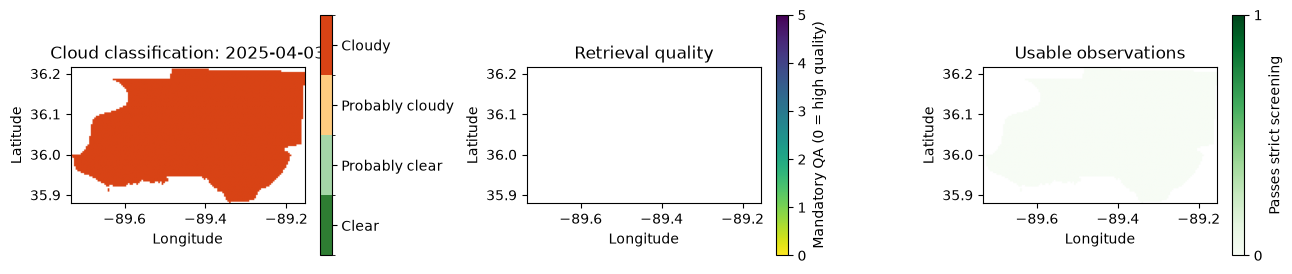

In [12]:
def reasons_for(i):
    valid_cloud = cloud[i] != 65535
    cls = (cloud[i] >> 6) & 3
    quality = (cloud[i] >> 4) & 3
    checks = {
        "radiance_missing_pct": ~np.isfinite(raw[i]),
        "cloud_mask_missing_pct": ~valid_cloud,
        "probably_or_confidently_cloudy_pct": valid_cloud & (cls >= 2),
        "probably_clear_pct": valid_cloud & (cls == 1),
        "cloud_quality_not_high_pct": valid_cloud & (quality != 3),
        "mandatory_not_high_quality_pct": mandatory[i] != 0,
        "snow_or_unknown_pct": snow[i] != 0,
        "strict_usable_pct": strict[i],
    }
    return {"date": labels[i], **{k: 100 * (v & county).sum() / county.sum() for k, v in checks.items()}}
rejections = pd.DataFrame([reasons_for(i) for i in range(len(dates))])
display(rejections.loc[event_idx].round(1))
i = labels.index(INSPECT_DATE)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
cloud_classes = np.where((cloud[i] != 65535) & county, (cloud[i] >> 6) & 3, np.nan)
from matplotlib.colors import ListedColormap, BoundaryNorm
cm = ListedColormap(["#2e7d32", "#a5d6a7", "#ffcc80", "#d84315"])
im = axes[0].imshow(cloud_classes, extent=extent, cmap=cm, norm=BoundaryNorm([-.5,.5,1.5,2.5,3.5], 4))
cb = fig.colorbar(im, ax=axes[0], ticks=[0,1,2,3], shrink=.65)
cb.ax.set_yticklabels(["Clear", "Probably clear", "Probably cloudy", "Cloudy"])
axes[0].set_title(f"Cloud classification: {INSPECT_DATE}")
im = axes[1].imshow(np.where(county & (mandatory[i] != 255), mandatory[i], np.nan), extent=extent, vmin=0, vmax=5, cmap="viridis_r")
fig.colorbar(im, ax=axes[1], shrink=.65, label="Mandatory QA (0 = high quality)")
axes[1].set_title("Retrieval quality")
im = axes[2].imshow(np.where(county, strict[i].astype(float), np.nan), extent=extent, vmin=0, vmax=1, cmap="Greens")
fig.colorbar(im, ax=axes[2], ticks=[0,1], shrink=.65, label="Passes strict screening")
axes[2].set_title("Usable observations")
for ax in axes: ax.set(xlabel="Longitude", ylabel="Latitude")
plt.tight_layout()
plt.show()

## A descriptive baseline: typical brightness and variability

Compute each cell's **median** and **interquartile range (IQR)** using only screened pre-event observations. The IQR measures historical variability, not a confidence interval. No cloud-gap interpolation is performed.

We require at least `MIN_BASELINE_NIGHTS` valid baseline observations for the displayed reference. This configurable support rule is provisional. A well-observed cell can still be too dark for outage detection.

baseline usable nights/cell (min, median, max): 0 26.0 34
event usable nights/cell (min, median, max): 0 8.0 10
Supported reference: 7,688/7,868 county cells


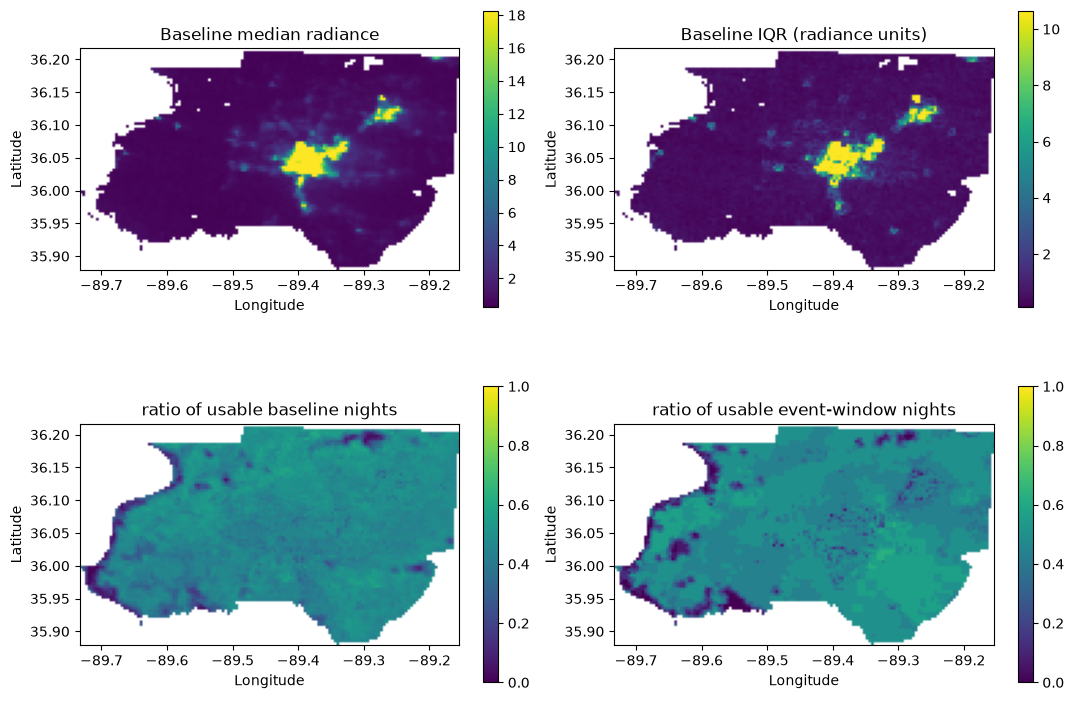

Radiance panels use a 98th-percentile display cap; exported values are not clipped.


In [15]:
baseline = observed[baseline_idx]
baseline_count = np.isfinite(baseline).sum(axis=0)
event_count = np.isfinite(observed[event_idx]).sum(axis=0)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="All-NaN slice encountered")
    median = np.nanmedian(baseline, axis=0)
    q25, q75 = np.nanpercentile(baseline, [25, 75], axis=0)
supported = county & (baseline_count >= MIN_BASELINE_NIGHTS)
reference = np.where(supported, median, np.nan)
iqr = np.where(supported, q75 - q25, np.nan)
assert supported.any(), "No cells meet the baseline support requirement"
for name, values in [("baseline", baseline_count), ("event", event_count)]:
    print(name, "usable nights/cell (min, median, max):", np.min(values[county]), np.median(values[county]), np.max(values[county]))
print(f"Supported reference: {supported.sum():,}/{county.sum():,} county cells")

def map_layer(ax, values, title, cmap="viridis", vmin=None, vmax=None):
    image = ax.imshow(np.where(county, values, np.nan), extent=extent, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel="Longitude", ylabel="Latitude")
    fig.colorbar(image, ax=ax, shrink=.75)
    return image

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
map_layer(axes[0,0], reference, "Baseline median radiance", vmax=np.nanpercentile(reference, 98))
map_layer(axes[0,1], iqr, "Baseline IQR (radiance units)", vmax=np.nanpercentile(iqr, 98))
# map_layer(axes[1,0], baseline_count.astype(float), "Usable baseline nights", vmin=0, vmax=int(baseline_idx.sum()))
# map_layer(axes[1,1], event_count.astype(float), "Usable event-window nights", vmin=0, vmax=int(event_idx.sum()))
map_layer(axes[1,0], baseline_count.astype(float)*1.0/baseline_idx.sum(), "ratio of usable baseline nights", vmin=0, vmax=1)
map_layer(axes[1,1], event_count.astype(float)*1.0/event_idx.sum(), "ratio of usable event-window nights", vmin=0, vmax=1)
plt.tight_layout()
plt.show()
print("Radiance panels use a 98th-percentile display cap; exported values are not clipped.")

## Compare individual event nights to the baseline

All radiance panels use the same display scale. Blank areas have insufficient observations or baseline support. Differences are computed only for usable observations with a supported reference. **A negative difference is not by itself evidence that power was lost.** These maps make no causal correction for normal temporal changes.

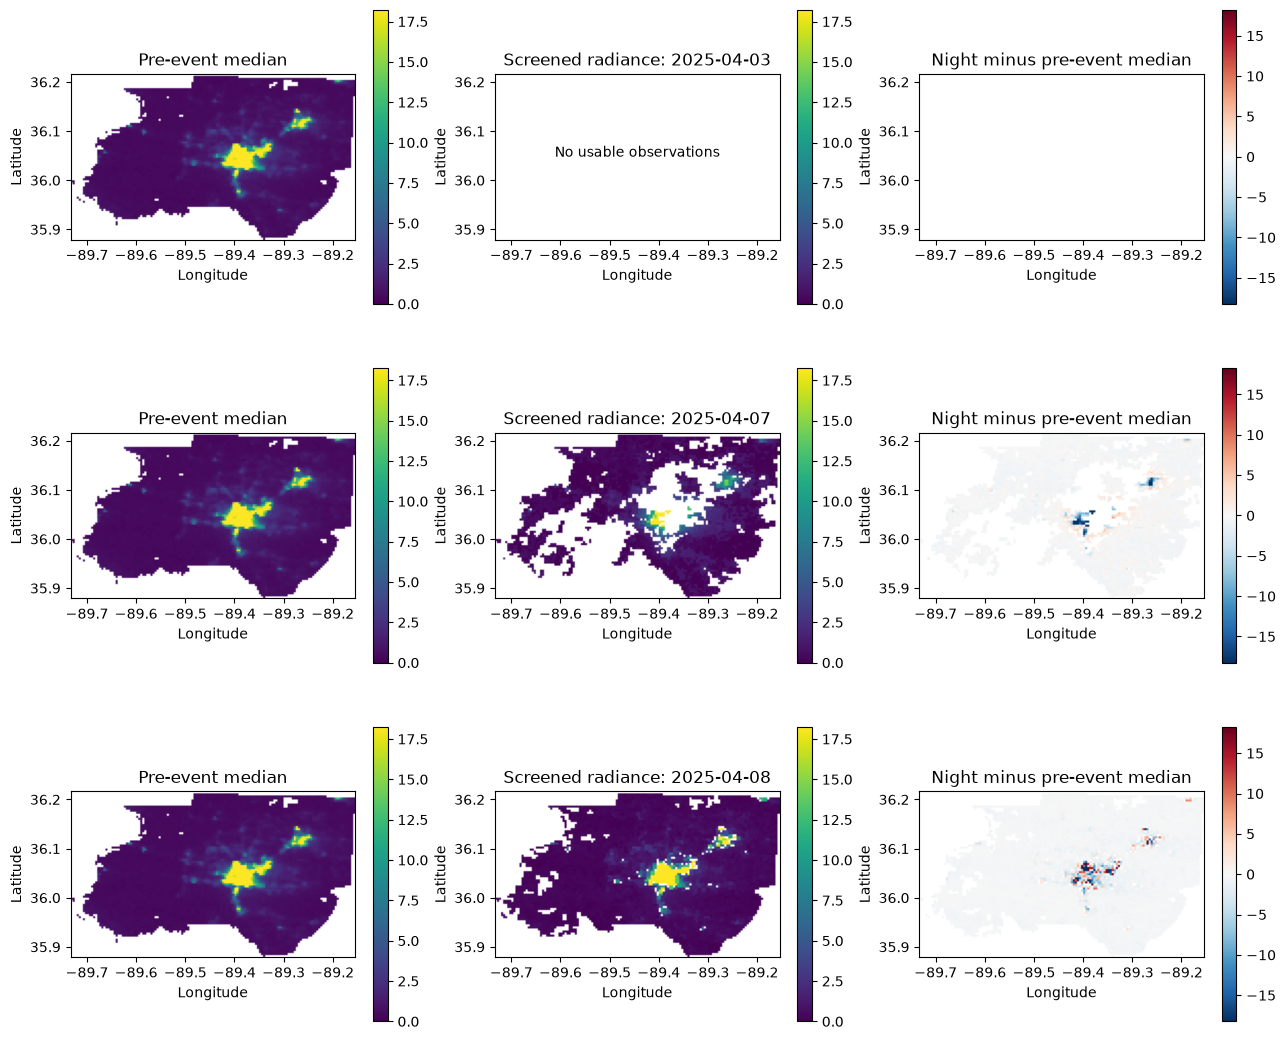

In [16]:
vmax = float(np.nanpercentile(reference, 98))
fig, axes = plt.subplots(len(MAP_DATES), 3, figsize=(13, 3.8 * len(MAP_DATES)), squeeze=False)
for row, day in enumerate(MAP_DATES):
    i = labels.index(day)
    nightly = observed[i]
    difference = np.where(supported, nightly - reference, np.nan)
    map_layer(axes[row,0], reference, "Pre-event median", vmin=0, vmax=vmax)
    map_layer(axes[row,1], nightly, f"Screened radiance: {day}", vmin=0, vmax=vmax)
    map_layer(axes[row,2], difference, "Night minus pre-event median", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    if not np.isfinite(nightly).any():
        axes[row,1].text(.5, .5, "No usable observations", ha="center", transform=axes[row,1].transAxes)
plt.tight_layout()
plt.show()

## Inspect a single cell through time

By default, choose the brightest supported cell **using baseline data only**. Set `CELL_LON_LAT` to a `(longitude, latitude)` pair to inspect another cell, then rerun this section. The IQR band is a descriptive baseline range, not prediction uncertainty.

The gap-filled line is shown to illustrate why it must not substitute for nightly observations: it may contain earlier information during cloudy periods. Connecting gap-filled points does not establish continuous power or an outage duration.

Cell row=37, column=80; center=(-89.397917, 36.060417); baseline support=25


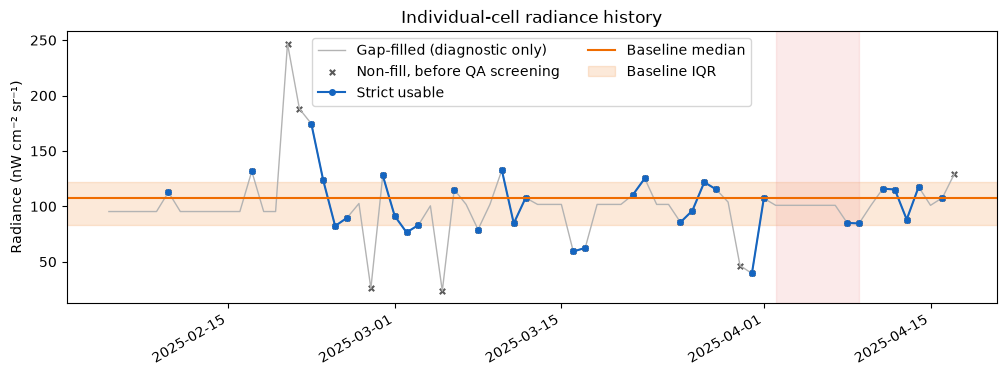

,date,screened_radiance,passes_screening,mandatory_quality
56,2025-04-02,NaN,False,255
57,2025-04-03,NaN,False,255
58,2025-04-04,NaN,False,255
59,2025-04-05,NaN,False,255
60,2025-04-06,NaN,False,255
61,2025-04-07,NaN,False,255
62,2025-04-08,85.083397,True,0
63,2025-04-09,84.594818,True,0
64,2025-04-10,NaN,False,255
65,2025-04-11,116.017136,True,0


In [17]:
CELL_LON_LAT = None  # Example: (-89.39, 36.03); use a coordinate from QGIS.
if CELL_LON_LAT is None:
    r, col = np.unravel_index(np.nanargmax(reference), reference.shape)
else:
    r, col = rowcol(affine, *CELL_LON_LAT)
    assert 0 <= r < shape[0] and 0 <= col < shape[1] and county[r, col], "Choose a cell inside Dyer County"
lon, lat = xy(affine, r, col)
print(f"Cell row={r}, column={col}; center=({lon:.6f}, {lat:.6f}); baseline support={baseline_count[r,col]}")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, gap_filled[:,r,col], color="0.7", linewidth=1, label="Gap-filled (diagnostic only)")
ax.scatter(dates, raw[:,r,col], s=15, color="0.35", marker="x", label="Non-fill, before QA screening")
ax.plot(dates, observed[:,r,col], "o-", color="#1565c0", markersize=4, label="Strict usable")
if supported[r,col]:
    ax.axhline(reference[r,col], color="#ef6c00", label="Baseline median")
    ax.axhspan(q25[r,col], q75[r,col], color="#ef6c00", alpha=.15, label="Baseline IQR")
ax.axvspan(pd.Timestamp("2025-04-02"), pd.Timestamp("2025-04-09"), color="#ef9a9a", alpha=.2)
ax.set(title="Individual-cell radiance history", ylabel="Radiance (nW cm⁻² sr⁻¹)")
ax.legend(ncol=2)
fig.autofmt_xdate()
plt.show()
display(pd.DataFrame({"date": labels, "screened_radiance": observed[:,r,col], "passes_screening": strict[:,r,col], "mandatory_quality": mandatory[:,r,col]}).loc[event_idx])

## Export inspection layers for QGIS

Exports go into the server's mounted `data/published/viirs_dyer/` directory. On the Mac, browse to **`~/mnt/ntl/published/viirs_dyer/`**.

The notebook writes baseline median/IQR, observation counts, masks, and selected event-date screened radiance and absolute difference maps. These are lossless COGs on the original grid. Floating outputs use NoData outside supported observations; count layers use NoData outside the county and retain zero counts inside it. Full per-night source radiance and QA COGs are already in `~/mnt/ntl/viirs/VNP46A2.002/dyer/`.

Close affected layers in QGIS before rerunning the export cell and reopen them afterward to avoid stale cached displays.

In [18]:
if WRITE_QGIS_EXPORTS:
    PUBLISH.mkdir(parents=True, exist_ok=True)
    def export_float(name, values):
        cog(PUBLISH / name, values.astype("float32"), affine, np.nan,
            description="Exploratory inspection output; not an outage classification", units="nW cm-2 sr-1")
    export_float("baseline_median.tif", reference)
    export_float("baseline_iqr.tif", iqr)
    for name, values in [("baseline_usable_nights", baseline_count), ("event_usable_nights", event_count)]:
        cog(PUBLISH / f"{name}.tif", np.where(county, values, 65535).astype("uint16"), affine, 65535, units="nights")
    cog(PUBLISH / "baseline_supported.tif", np.where(county, supported.astype("uint8"), 255).astype("uint8"), affine, 255)
    cog(PUBLISH / "county_mask.tif", county.astype("uint8"), affine, None)
    for day in MAP_DATES:
        i = labels.index(day)
        export_float(f"daily/{day}/screened_radiance.tif", observed[i])
        export_float(f"daily/{day}/difference_from_baseline.tif", np.where(supported, observed[i] - reference, np.nan))
    rejections.to_csv(PUBLISH / "quality_diagnostics.csv", index=False)
    coverage.to_csv(PUBLISH / "nightly_coverage.csv", index=False)
    save_json(PUBLISH / "provenance.json", {
        "source_manifest_sha256": digest(DATA / "manifest.json"),
        "source_inventory_sha256": digest(DATA / "inventory.json"),
        "baseline_end": BASELINE_END, "min_baseline_nights": MIN_BASELINE_NIGHTS,
        "map_dates": MAP_DATES, "notebook": "notebooks/02_inspect_viirs.ipynb",
        "screening": "Uses cached strict_usable masks; no TING inputs",
        "output_sha256": {str(p.relative_to(PUBLISH)): digest(p) for p in sorted(PUBLISH.rglob("*.tif"))},
    })
    (PUBLISH / "README.txt").write_text(
        "Dyer County VIIRS inspection layers; NOT outage maps.\n"
        "Baseline: 2025-02-05 through " + BASELINE_END + "; minimum " + str(MIN_BASELINE_NIGHTS) + " usable nights.\n"
        "Median/IQR and daily differences: nW cm^-2 sr^-1. IQR is variability, not a confidence interval.\n"
        "Usable-night counts retain zero inside county; NoData outside county.\n"
        "Blank daily maps mean no supported observations, not no outages.\n"
        "Suggested styles: median/IQR = sequential; differences = diverging centered at zero; counts = sequential.\n"
        "Source QA and raw radiance: ../../viirs/VNP46A2.002/dyer/YYYY-MM-DD/.\n"
    )
    print("Published to", PUBLISH)
    print("Mac mount: ~/mnt/ntl/published/viirs_dyer/")
else:
    print("Exports disabled")

Published to /home/daynan/research/ntl-outage-detection/data/published/viirs_dyer
Mac mount: ~/mnt/ntl/published/viirs_dyer/


## Interpretation before modeling

- Do sufficiently bright cells have enough valid pre-event observations for a stable reference?
- Do large baseline IQR values indicate cells that need a more flexible normal-state model?
- Which event dates are unobservable, and which screening flags explain that?
- Does the gap-filled layer conceal gaps that are explicit in the measured series?
- Are there useful event-night deviations in cells with reliable baseline support?

Keep TING out of these choices. These diagnostics prepare the satellite inputs; outage attribution and independent TING validation remain separate later steps.